## Droplet dynamics (turbulent fluid)

Reference: Binary-fluid turbulence: Signatures of multifractal droplet dynamics and dissipation reduction
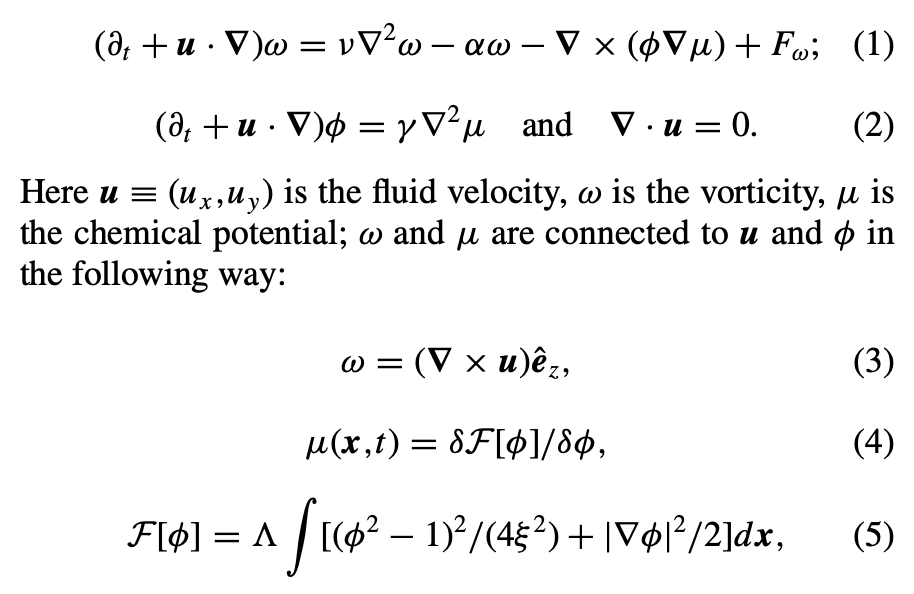
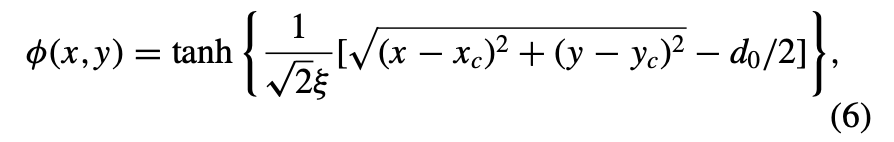

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime

In [ ]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx
# 0.03
# 4*dx

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0.03
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 4e-4
# 6e-4
# epsilon**2

# Low sigma could break the interface
sigma = 1.0

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 4.0
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 3
# 4 
# also epsilon, alpha, nu, M

# Kolmogorov-type forcing
# f_w = f_0 * (np.cos(k_f * Y))
f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
f_w_hat = np.fft.fft2(f_w)

# Time stepping
T = 8.0
N_t = 25000
delta_t = T/N_t
save_every = 100

# T = 5.0
# N_t = 2500
# delta_t = T/N_t
# save_every = 100

# Single droplet parameters

xc = L_x / 2
yc = L_y / 2

# xc = 0.47 * L_x
# yc = 0.41 * L_y

d0 = 0.24 * L_x      
# xi = 0.004 * L_x

In [3]:
experiment_name = "Experiment_05"

def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [4]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "increased sigma,k_f",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        "type": "Kolmogorov-type forcing",
        "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * cos(k_f * Y)",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },


    # Droplet initial condition
    "initial_condition": {
        "type": "single droplet",
        "xc": float(xc),
        "yc": float(yc),
        "d0": float(d0),
        "d0_relative_to_Lx": float(d0 / L_x),
        "center_definition": "xc = L_x / 2, yc = L_y / 2",
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / "parameters.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_05/parameters.json


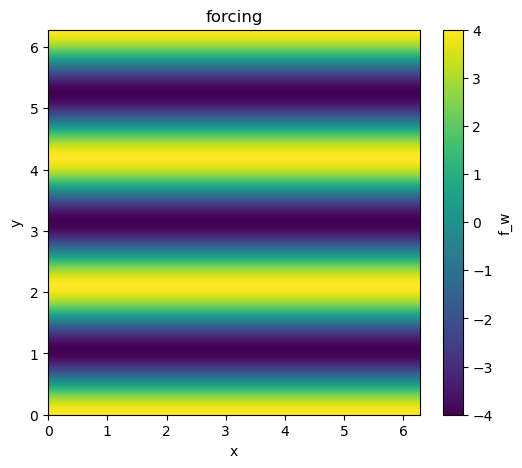

In [5]:
plt.figure(figsize=(6,5))
plt.imshow(f_w, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='f_w')
plt.title('forcing')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
# # Reference: Efficient Coding of the Minimum Image Convention
# # Instead of the Euclidean distance, the minimum image convention is implemented for periodic BCs

# def periodic_distance(X, Y, xc, yc, Lx, Ly):
#     dx = X - xc
#     dy = Y - yc
#     # dx = (dx + Lx/2) % Lx - Lx/2
#     # dy = (dy + Ly/2) % Ly - Ly/2
#     return np.sqrt(dx**2 + dy**2)

# def build_phi_rp2(X, Y, centers, radii, epsilon, Lx, Ly):
#     phi = np.zeros_like(X)
#     Nd = len(centers)

#     for (xc, yc), R in zip(centers, radii):
#         r = periodic_distance(X, Y, xc, yc, Lx, Ly)
#         phi += np.tanh((R - r)/epsilon)

#     phi += (Nd - 1)
#     return phi

In [7]:
def single_droplet_phi(X, Y, xc, yc, d0, xi):
    """
    Diffuse single-droplet initial condition matching the paper's convention:
        phi < 0 inside droplet
        phi > 0 in background

    Parameters
    ----------
    X, Y : 2D arrays
        Meshgrid arrays.
    xc, yc : float
        Droplet center.
    d0 : float
        Droplet diameter.
    xi : float
        Diffuse interface width parameter from the paper.
    """
    r = np.sqrt((X - xc)**2 + (Y - yc)**2)
    return np.tanh((r - d0/2) / (2.0 * epsilon))

# Initialise phi
phi_xy = single_droplet_phi(X, Y, xc, yc, d0, epsilon)
phi_xy_hat = np.fft.fft2(phi_xy)

# Initial vorticity
omega_xy_0 = np.zeros((N_y, N_x))
omega_hat = np.fft.fft2(omega_xy_0)

In [8]:
# Initial set-up

# def make_square_droplet_array(Lx, Ly, nx, ny, margin_x=np.pi, margin_y=np.pi):
#     """
#     Create a regular nx-by-ny array of droplet centers in a periodic box.
#     margin_x, margin_y let you keep droplets away from the edges if desired.
#     """
#     xs = np.linspace(margin_x, Lx - margin_x, nx, endpoint=False)
#     ys = np.linspace(margin_y, Ly - margin_y, ny, endpoint=False)

#     centers = []
#     for y in ys:
#         for x in xs:
#             centers.append((x, y))
#     return centers

# # Dense droplet lattice (nx is the no. of droplets)
# centers = make_square_droplet_array(L_x, L_y, nx=1, ny=1)

# # Same radius for all droplets
# radii = [R] * len(centers)

# # phi

# # phi_xy = np.zeros((N_y, N_x)) # only for laminar flow
# phi_xy = build_phi_rp2(X, Y, centers, radii, epsilon, L_x, L_y)
# phi_xy_hat = np.fft.fft2(phi_xy)



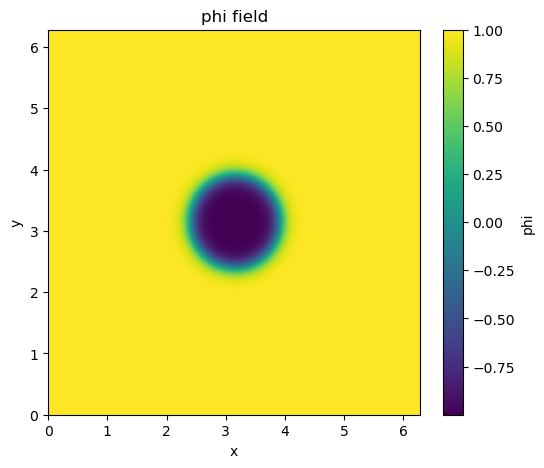

In [9]:
plt.figure(figsize=(6,5))
plt.imshow(phi_xy, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='phi')
plt.title('phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [10]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [11]:
# Assemble \mu using pseudo-spectral implementation

print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)

initial phi stats: -0.9999285768514409 1.0 0.9066834837109465
initial phi hat finite? True


In [12]:
# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [13]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [14]:
# Extraction of droplet geometry from phi

def polygon_area(x, y):
    """
    Shoelace formula for area of a closed polygon.
    """
    return 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_perimeter(x, y, closed=True):
    """
    Perimeter of a polygonal curve.
    """
    if closed:
        dx = np.diff(np.r_[x, x[0]])
        dy = np.diff(np.r_[y, y[0]])
    else:
        dx = np.diff(x)
        dy = np.diff(y)
    return np.sum(np.sqrt(dx**2 + dy**2))


def contour_pixels_to_physical(contour_rc, dx, dy):
    """
    skimage.find_contours returns coordinates as (row, col).
    Convert to physical x,y coordinates.
    """
    r = contour_rc[:, 0]
    c = contour_rc[:, 1]
    x = c * dx
    y = r * dy
    return x, y


def effective_diameter_from_area(A):
    """
    d_p = 2 * sqrt(A / pi)
    """
    return 2.0 * np.sqrt(A / np.pi)


def reference_circle_perimeter_from_area(A):
    """
    Perimeter of a circle with the same area A.
    S0 = pi * d_p = 2 * sqrt(pi A)
    """
    return 2.0 * np.sqrt(np.pi * A)


def deformation_parameter(S, A):
    """
    Gamma = S / S0 - 1
    """
    S0 = reference_circle_perimeter_from_area(A)
    return S / S0 - 1.0


def periodic_center_of_mass(mask, Lx, Ly):
    """
    Periodic-safe center of mass of a boolean mask.
    This avoids jumps when the droplet crosses the periodic boundary.
    """
    Ny, Nx = mask.shape

    # x coordinates
    x_idx = np.arange(Nx)
    theta_x = 2.0 * np.pi * x_idx / Nx
    wx = mask.sum(axis=0).astype(float)
    if wx.sum() == 0:
        return np.nan, np.nan

    Cx = np.sum(wx * np.cos(theta_x)) / np.sum(wx)
    Sx = np.sum(wx * np.sin(theta_x)) / np.sum(wx)
    ang_x = np.arctan2(Sx, Cx) % (2.0 * np.pi)
    x_cm = Lx * ang_x / (2.0 * np.pi)

    # y coordinates
    y_idx = np.arange(Ny)
    theta_y = 2.0 * np.pi * y_idx / Ny
    wy = mask.sum(axis=1).astype(float)
    Cy = np.sum(wy * np.cos(theta_y)) / np.sum(wy)
    Sy = np.sum(wy * np.sin(theta_y)) / np.sum(wy)
    ang_y = np.arctan2(Sy, Cy) % (2.0 * np.pi)
    y_cm = Ly * ang_y / (2.0 * np.pi)

    return x_cm, y_cm


def extract_main_droplet_contour(phi_xy, level=0.0):
    """
    Extract all level-set contours and return the longest one.
    For a single-droplet setup, this is usually the main droplet boundary.
    """
    contours = measure.find_contours(phi_xy, level=level)

    if len(contours) == 0:
        return None

    # choose the longest contour in number of points
    contour = max(contours, key=lambda c: c.shape[0])
    return contour


def droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0):
    """
    Compute droplet geometry from the phi=0 contour and phi<0 interior.

    Returns a dictionary with:
        area
        perimeter
        diameter
        gamma
        S0
        x_cm
        y_cm
        area_from_mask
        contour_xy
    """
    contour_rc = extract_main_droplet_contour(phi_xy, level=level)
    if contour_rc is None:
        return None

    # Contour-based geometry
    x_contour, y_contour = contour_pixels_to_physical(contour_rc, dx, dy)
    A_contour = polygon_area(x_contour, y_contour)
    S_contour = polygon_perimeter(x_contour, y_contour, closed=True)

    # Effective diameter and deformation
    d_p = effective_diameter_from_area(A_contour)
    S0 = reference_circle_perimeter_from_area(A_contour)
    Gamma = deformation_parameter(S_contour, A_contour)

    # Mask-based area and COM
    mask = (phi_xy < 0.0)
    A_mask = np.sum(mask) * dx * dy
    x_cm, y_cm = periodic_center_of_mass(mask, Lx, Ly)

    return {
        "area": A_contour,
        "perimeter": S_contour,
        "diameter": d_p,
        "gamma": Gamma,
        "S0": S0,
        "x_cm": x_cm,
        "y_cm": y_cm,
        "area_from_mask": A_mask,
        "contour_x": x_contour,
        "contour_y": y_contour,
    }


In [15]:
def initialize_droplet_tracking():
    return {
        "time": [],
        "area": [],
        "area_mask": [],
        "area_rel_error": [],
        "perimeter": [],
        "S0": [],
        "gamma": [],
        "diameter": [],
        "x_cm": [],
        "y_cm": [],
    }

# Updating function during simulation
def update_droplet_tracking(track, t, phi_xy, dx, dy, Lx, Ly, A0=None):
    geom = droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0)

    if geom is None:
        return track, A0

    if A0 is None:
        A0 = geom["area"]

    rel_err = (geom["area"] - A0) / A0

    track["time"].append(t)
    track["area"].append(geom["area"])
    track["area_mask"].append(geom["area_from_mask"])
    track["area_rel_error"].append(rel_err)
    track["perimeter"].append(geom["perimeter"])
    track["S0"].append(geom["S0"])
    track["gamma"].append(geom["gamma"])
    track["diameter"].append(geom["diameter"])
    track["x_cm"].append(geom["x_cm"])
    track["y_cm"].append(geom["y_cm"])

    return track, A0

In [16]:
# Time stepping 

G = lambda omega_hat,phi_xy,mu_s,u_x,u_y: -(advection_omega(omega_hat,u_x,u_y)) + coupling_term(phi_xy,mu_s) + f_w_hat
H = lambda phi_xy_hat,phi_xy,u_x,u_y: -(advection_phi(phi_xy_hat,u_x,u_y)) - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))


In [17]:
# Time stepping
q_01 = omega_hat
q_02 = phi_xy_hat

q_01_n = q_01
q_02_n = q_02

omega_history = [omega_xy_0.copy()]
phi_history = [np.fft.ifft2(q_02_n).real.copy()]
time_history = [0.0]

track = initialize_droplet_tracking()
A0 = None

# track initial condition
phi0 = np.fft.ifft2(phi_xy_hat).real
track, A0 = update_droplet_tracking(track, 0.0, phi0, del_x, del_y, L_x, L_y, A0=A0)

# Masked handling for lambda = 0
E_01 = np.exp(lamda_01*delta_t)
E_02 = np.exp(lamda_02*delta_t)

mask_01 = (np.abs(lamda_01) > 1e-14)
mask_02 = (np.abs(lamda_02) > 1e-14)

# Masked handling for lambda = 0

phi1 = np.empty_like(lamda_01, dtype=complex)
phi2 = np.empty_like(lamda_02, dtype=complex)

phi1[mask_01] = (E_01[mask_01] - 1)/lamda_01[mask_01]
phi2[mask_02] = (E_02[mask_02] - 1)/lamda_02[mask_02]

phi1[~mask_01] = delta_t
phi2[~mask_02] = delta_t

phi_1 = np.empty_like(lamda_01, dtype=complex)
phi_2 = np.empty_like(lamda_02, dtype=complex)

phi_1[mask_01] = (E_01[mask_01] - 1 - lamda_01[mask_01] * delta_t)/(lamda_01[mask_01]**2 * delta_t)
phi_2[mask_02] = (E_02[mask_02] - 1 - lamda_02[mask_02] * delta_t)/(lamda_02[mask_02]**2 * delta_t)

phi_1[~mask_01] = 0.5 * delta_t
phi_2[~mask_02] = 0.5 * delta_t

for n in range(0,N_t):
    t = n * delta_t
    # Block A: Recomputation

    # A.1) Extracting velocity from omega_hat_n
    u_x_n,u_y_n = recover_velocity(q_01_n)

    # A.2) Re-computing terms
    phi_intermediate = np.fft.ifft2(q_02_n).real
    mu_spec_n = mu_spec(q_02_n,phi_intermediate)

    # A.3) Non-linear terms
    G_n = G(q_01_n,phi_intermediate,mu_spec_n,u_x_n,u_y_n)
    H_n = H(q_02_n,phi_intermediate,u_x_n,u_y_n)

    # Block B: Predictor

    a_01_n = q_01_n * np.exp(lamda_01 * delta_t) + (G_n * phi1)
    a_02_n = q_02_n * np.exp(lamda_02 * delta_t) + (H_n * phi2)

    # Block C: Intermediate state reconstruction
    # C.1) Recover velocity from a_01_n
    u_x_a, u_y_a = recover_velocity(a_01_n)

    # C.2) Recover phi from a_02_n
    phi_a = np.fft.ifft2(a_02_n).real
    mu_spec_a = mu_spec(a_02_n,phi_a)

    # Block D: Final assembly

    G_a = G(a_01_n,phi_a,mu_spec_a,u_x_a,u_y_a)
    H_a = H(a_02_n,phi_a,u_x_a,u_y_a)

    q_01_next = a_01_n + (G_a - G_n) * phi_1
    q_02_next = a_02_n + (H_a - H_n) * phi_2

    if not np.isfinite(q_01_next).all() or not np.isfinite(q_02_next).all():
        print("NaN/Inf detected at step", n)
        break

    q_01_next = dealias(q_01_next)
    q_02_next = dealias(q_02_next)

    if n % save_every == 0:
        track, A0 = update_droplet_tracking(
            track, t, np.fft.ifft2(q_02_next).real, del_x, del_y, L_x, L_y, A0=A0
        )
        omega_history.append(np.fft.ifft2(q_01_next).real.copy())
        phi_history.append(np.fft.ifft2(q_02_next).real.copy())
        time_history.append(n * delta_t)

    if n % save_every == 0:
        print(f"step {n}/{N_t}")
    
    # Final omega hat
    q_01_n = q_01_next
    # omega_history.append(np.fft.ifft2(q_01_n).real)

    # Final phi_hat
    q_02_n = q_02_next
    # phi_history.append(np.fft.ifft2(q_02_n).real)

for key in track:
    track[key] = np.array(track[key])


step 0/25000
step 100/25000
step 200/25000
step 300/25000
step 400/25000
step 500/25000
step 600/25000
step 700/25000
step 800/25000
step 900/25000
step 1000/25000
step 1100/25000
step 1200/25000
step 1300/25000
step 1400/25000
step 1500/25000
step 1600/25000
step 1700/25000
step 1800/25000
step 1900/25000
step 2000/25000
step 2100/25000
step 2200/25000
step 2300/25000
step 2400/25000
step 2500/25000
step 2600/25000
step 2700/25000
step 2800/25000
step 2900/25000
step 3000/25000
step 3100/25000
step 3200/25000
step 3300/25000
step 3400/25000
step 3500/25000
step 3600/25000
step 3700/25000
step 3800/25000
step 3900/25000
step 4000/25000
step 4100/25000
step 4200/25000
step 4300/25000
step 4400/25000
step 4500/25000
step 4600/25000
step 4700/25000
step 4800/25000
step 4900/25000
step 5000/25000
step 5100/25000
step 5200/25000
step 5300/25000
step 5400/25000
step 5500/25000
step 5600/25000
step 5700/25000
step 5800/25000
step 5900/25000
step 6000/25000
step 6100/25000
step 6200/25000
step

In [18]:
print("Run completed with T =", T, "N_t =", N_t, "delta_t =", delta_t)
print("omega final min/max:", omega_history[-1].min(), omega_history[-1].max())
print("len(omega_history) =", len(omega_history))

Run completed with T = 8.0 N_t = 25000 delta_t = 0.00032
omega final min/max: -10.025908628474335 7.302662042441866
len(omega_history) = 251


In [19]:
print("final phi stats:", phi_history[-1].min(), phi_history[-1].max(), np.mean(phi_history[-1]))
print("final omega stats:", omega_history[-1].min(), omega_history[-1].max())
print("all phi finite?", np.isfinite(np.array(phi_history)).all())
print("all omega finite?", np.isfinite(np.array(omega_history)).all())

final phi stats: -1.0509762024519755 1.0104128611893803 0.9066834837109464
final omega stats: -10.025908628474335 7.302662042441866
all phi finite? True
all omega finite? True


In [20]:
# Pointers

## 1) may need to use Google Collab, numpy might be too slow
## 2) Validation Techniques - look up research papers on it - vary time-stepping techniques/grid points & compute the error 
## 3) Simulate phase separation
## 4) Look up on relations between parameters 
## 5) Additional - Mean square displacement

In [21]:
phi_mean = []

for i in range(len(phi_history)):
    phi_mean.append(np.mean(phi_history[i]))

phi_mean_check = np.array(phi_mean)   # one value per time step
m0 = phi_mean[0]

abs_drift = np.abs(phi_mean_check - m0)
rel_drift = abs_drift / max(abs(m0), 1e-14)

print("max abs drift =", abs_drift.max())
print("max rel drift =", rel_drift.max())
print(m0)


max abs drift = 2.220446049250313e-16
max rel drift = 2.448975953727859e-16
0.9066834837109465


In [22]:
# Since m0 is almost close to roundoff-level zero, dividing by such a number results into 
# arbitrarily large output. Thus, we use abs_drift. 

# plt.semilogy(abs_drift)
# plt.semilogy(rel_drift)

In [23]:
phi_max = []

for i in range(len(phi_history)):
    phi_max.append(np.max(np.abs(phi_history[i])))

omega_max = []

for i in range(len(omega_history)):
    omega_max.append(np.max(np.abs(omega_history[i])))

phi_max_check = np.array(phi_max)
omega_max_check = np.array(omega_max)

print("max |phi| =", phi_max_check.max())
print("max |omega| =", omega_max_check.max())
print("all finite phi?", np.isfinite(phi_max_check).all())
print("all finite omega?", np.isfinite(omega_max_check).all())


max |phi| = 1.0746591183801653
max |omega| = 21.20528234956517
all finite phi? True
all finite omega? True


Text(0.5, 1.0, 'max |omega| over time')

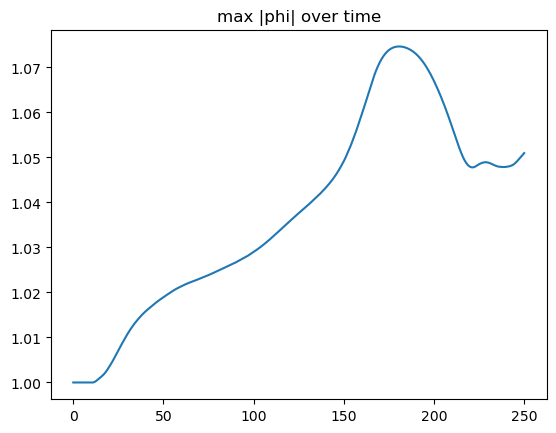

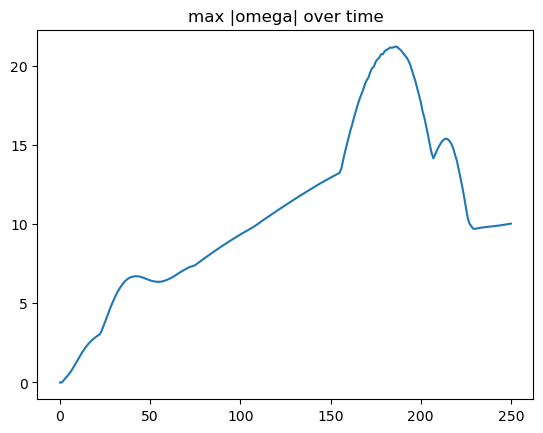

In [24]:
plt.plot(phi_max)
plt.title("max |phi| over time")

plt.figure()
plt.plot(omega_max)
plt.title("max |omega| over time")

In [25]:
omega_xy_final = np.fft.ifft2(q_01_n).real
phi_xy_final   = np.fft.ifft2(q_02_n).real

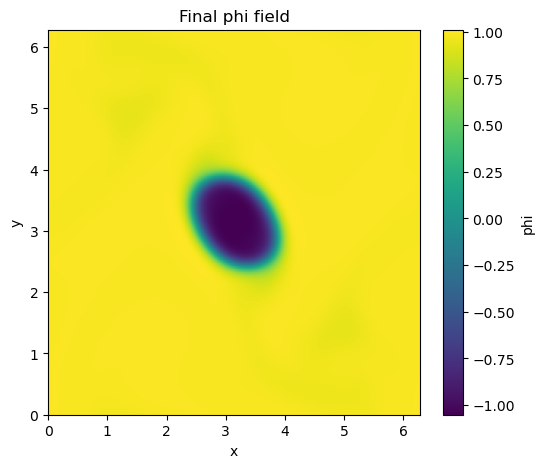

In [26]:
plt.figure(figsize=(6,5))
plt.imshow(phi_xy_final, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='phi')
plt.title('Final phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

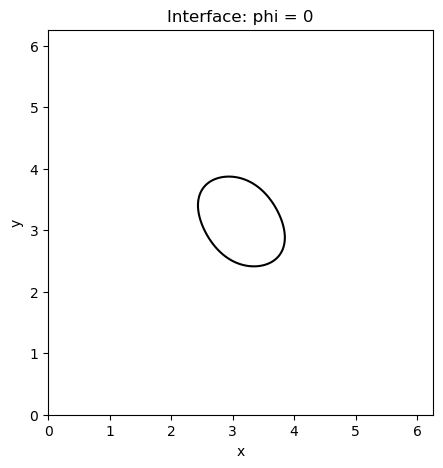

In [27]:
plt.figure(figsize=(6,5))
plt.contour(X, Y, phi_xy_final, levels=[0], colors='k')
plt.title('Interface: phi = 0')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.show()

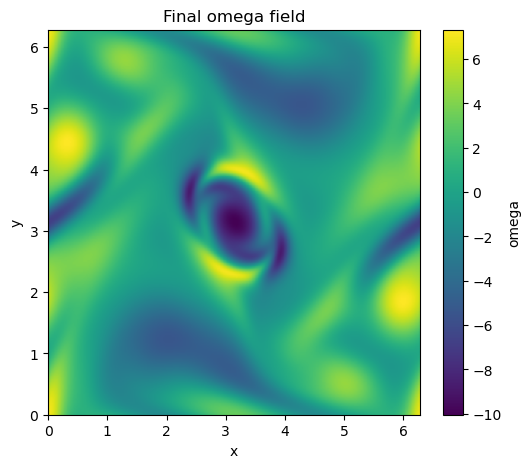

In [28]:
plt.figure(figsize=(6,5))
plt.imshow(omega_xy_final, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='omega')
plt.title('Final omega field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

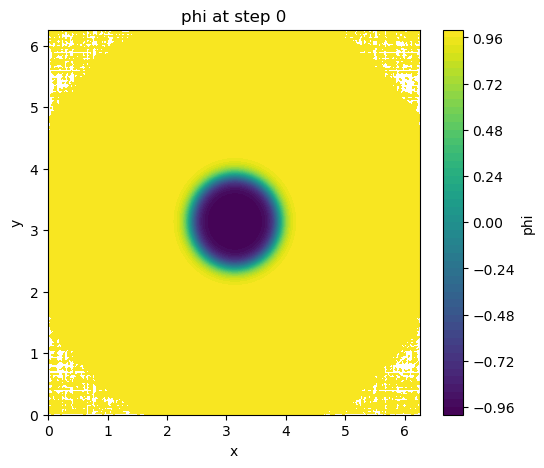

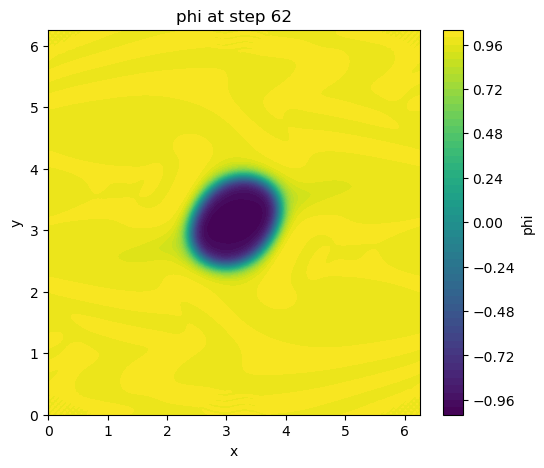

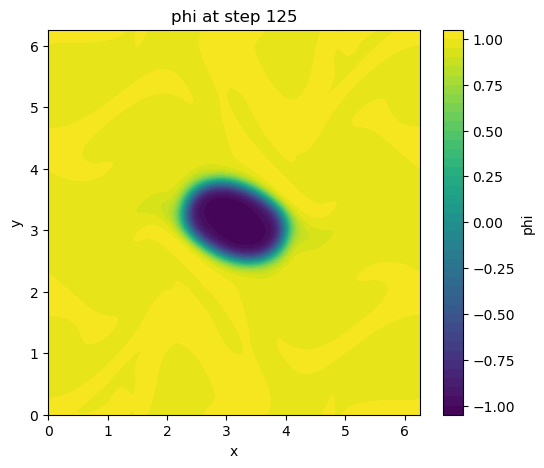

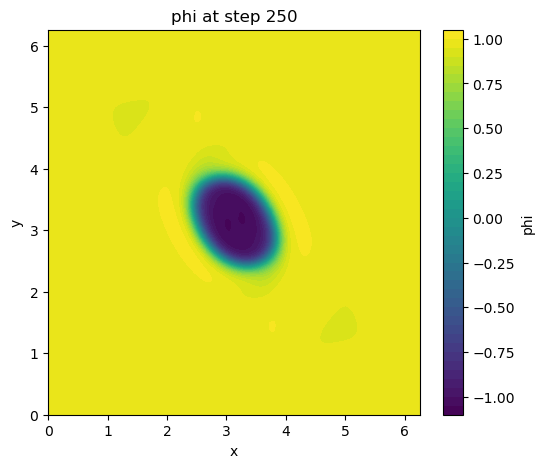

In [29]:
times_to_plot = [0, len(phi_history)//4,len(phi_history)//2, len(phi_history)-1]

for idx in times_to_plot:
    plt.figure(figsize=(6,5))
    plt.contourf(X, Y, phi_history[idx], levels=50)
    plt.colorbar(label='phi')
    plt.title(f'phi at step {idx}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

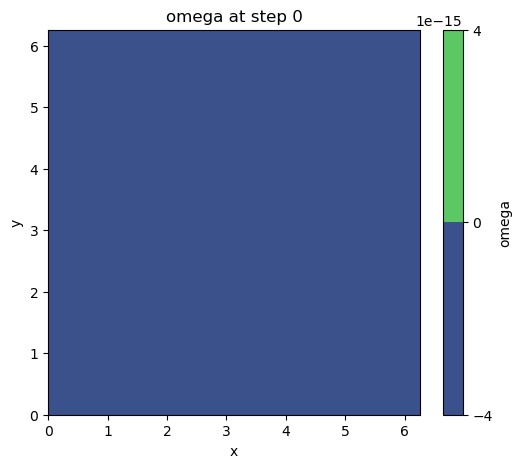

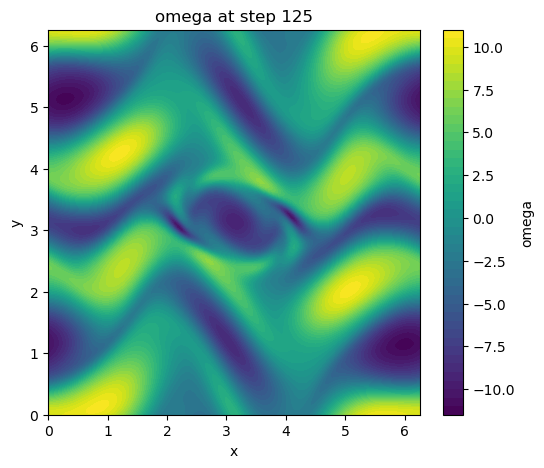

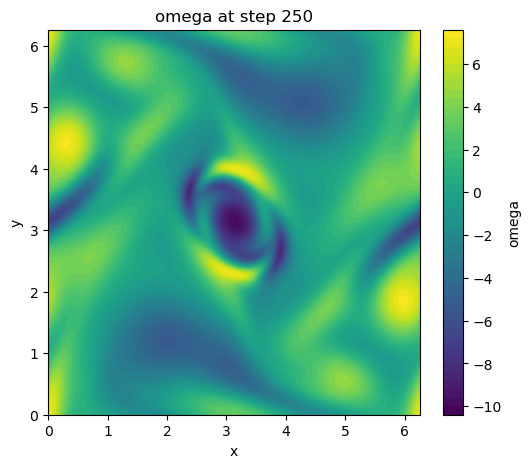

In [30]:
times_to_plot = [0, len(omega_history)//2, len(omega_history)-1]

for idx in times_to_plot:
    plt.figure(figsize=(6,5))
    plt.contourf(X, Y, omega_history[idx], levels=50)
    plt.colorbar(label='omega')
    plt.title(f'omega at step {idx}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

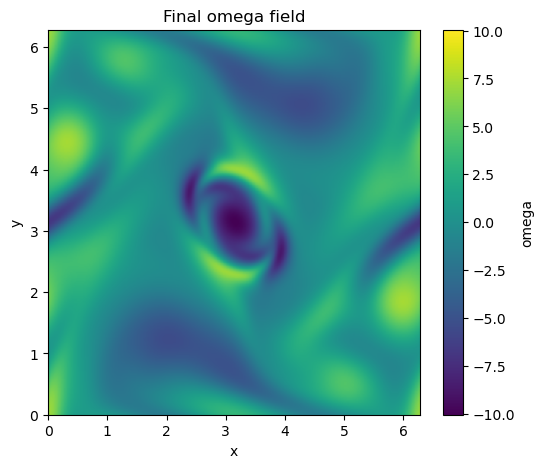

In [31]:
om = omega_xy_final
v = np.max(np.abs(om))

plt.figure(figsize=(6,5))
plt.imshow(om, origin='lower', extent=[0, L_x, 0, L_y], vmin=-v, vmax=v, aspect='auto')
plt.colorbar(label='omega')
plt.title('Final omega field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_omega_with_contour_imshow(omega_history, phi_history, time_history, L_x, L_y,
                                      interval=100):
    omega_history = np.asarray(omega_history)
    phi_history = np.asarray(phi_history)
    time_history = np.asarray(time_history)

    fig, ax = plt.subplots(figsize=(6, 6))

    vmin = np.min(omega_history)
    vmax = np.max(omega_history)

    im = ax.imshow(
        omega_history[0],
        origin="lower",
        extent=[0, L_x, 0, L_y],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        aspect="equal"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("omega")

    contour = ax.contour(
        np.linspace(0, L_x, phi_history.shape[2]),
        np.linspace(0, L_y, phi_history.shape[1]),
        phi_history[0],
        levels=[0.0],
        colors="k",
        linewidths=2
    )

    title = ax.set_title(f"omega with droplet contour, t = {time_history[0]:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(frame):
        nonlocal contour

        im.set_data(omega_history[frame])

        if contour is not None:
            contour.remove()

        contour = ax.contour(
            np.linspace(0, L_x, phi_history.shape[2]),
            np.linspace(0, L_y, phi_history.shape[1]),
            phi_history[frame],
            levels=[0.0],
            colors="k",
            linewidths=2
        )

        title.set_text(f"omega with droplet contour, t = {time_history[frame]:.4f}")
        return [im, title]

    anim = FuncAnimation(fig, update, frames=len(time_history), interval=interval, blit=False)
    plt.close(fig)
    return anim

anim = animate_omega_with_contour_imshow(
    omega_history=omega_history,
    phi_history=phi_history,
    time_history=time_history,
    L_x=L_x,
    L_y=L_y,
    interval=120
)


output_path = animations_dir / "omega_with_contour.gif"
anim.save(output_path, writer="pillow", fps=8)
print(f"Saved omega animation to {output_path}")

Saved omega animation to Results/Experiment_05/omega_with_contour.gif


Saved phi animation to Results/Experiment_05/phi_animation_dd.gif


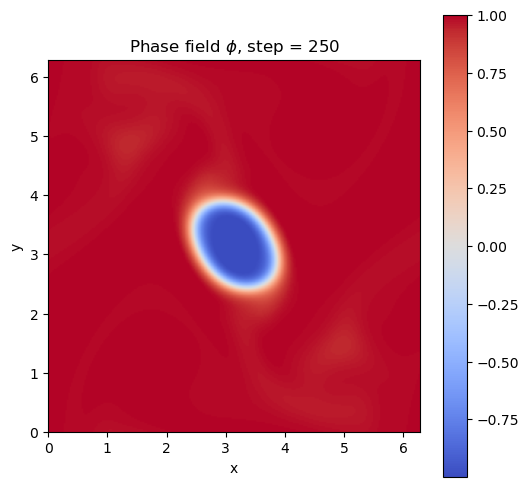

In [33]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    phi_history[0],
    origin='lower',
    extent=[0, L_x, 0, L_y],
    cmap='coolwarm',
    animated=True
)
ax.set_title("Phase field $\\phi$")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(phi_history[frame])
    ax.set_title(f"Phase field $\\phi$, step = {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(phi_history),
    interval=50,
    blit=True
)

output_path = animations_dir / "phi_animation_dd.gif"
ani.save(output_path, writer="pillow", fps=15)
print(f"Saved phi animation to {output_path}")

In [34]:
print(phi_history[0].min(), phi_history[0].max(), np.mean(phi_history[0]))

-0.9999285768514404 1.0000000000000007 0.9066834837109465


### Validation:

#### Check 01 - Single-fluid laminar cellular solution (phi,omega = 0 and alpha = 0)
#### Check 02 — Initial droplet-field validation
#### Check 03 — Conservation and numerical stability (for full CHNS with forcing)
#### Check 04 - Energy and coarsening diagnostics
#### Check 05 - Regime classification and refinement

In [35]:
# omega_lam = -(f_0 / (nu * k_f)) * (np.cos(k_f * X) + np.cos(k_f * Y))

# omega_num = omega_history[-1]
# err = omega_num - omega_lam

# err_L2 = np.sqrt(1/(N_x*N_y)*np.sum(np.sum(np.abs(err)**2)))
# err_Linf = np.max(np.abs(err))

# print("Laminar validation:")
# print("L2 error   =", err_L2)
# print("Linf error =", err_Linf)

In [36]:
# Validation 02: Conservation and numerical stability

phi_mean_hist = [np.mean(phi) for phi in phi_history]
phi_min_hist  = [np.min(phi) for phi in phi_history]
phi_max_hist  = [np.max(phi) for phi in phi_history]

omega_min_hist = [np.min(w) for w in omega_history]
omega_max_hist = [np.max(w) for w in omega_history]

print("Mean phi drift =", np.max(np.abs(np.array(phi_mean_hist) - phi_mean_hist[0])))
print("All phi finite?  ", np.isfinite(np.array(phi_history)).all())
print("All omega finite?", np.isfinite(np.array(omega_history)).all())

Mean phi drift = 2.220446049250313e-16
All phi finite?   True
All omega finite? True


In [37]:
# Validation 03: Energy and coarsening diagnostics

# Kinetic energy
energy_hist = []

for w_hat in [np.fft.fft2(w) for w in omega_history]:
    u_x, u_y = recover_velocity(w_hat)
    e_t = 0.5 * np.mean(u_x**2 + u_y**2)
    energy_hist.append(e_t)

# Shell-averaged phase spectrum and coarsening length

def shell_average_phi(phi_hat, K2):
    k_mag = np.sqrt(K2)
    k_max = int(np.floor(np.max(k_mag)))
    S = np.zeros(k_max + 1)

    for k in range(k_max + 1):
        mask = (k_mag >= k) & (k_mag < k + 1)
        if np.any(mask):
            S[k] = np.sum(np.abs(phi_hat[mask])**2)
    return S

L_hist = []

for phi in phi_history:
    phi_hat = np.fft.fft2(phi)
    S = shell_average_phi(phi_hat, K2)
    kvals = np.arange(len(S))

    # Exclude k=0 shell
    S_use = S[1:]
    k_use = kvals[1:]

    numer = np.sum(S_use)
    denom = np.sum(k_use * S_use)

    if denom > 1e-14 and numer > 1e-14:
        L_t = 2*np.pi * numer / denom
    else:
        L_t = np.nan

    L_hist.append(L_t)

L_arr = np.array(L_hist)

print("L(t) stats:")
print("min =", np.nanmin(L_arr))
print("max =", np.nanmax(L_arr))
print("all finite?", np.isfinite(L_arr).all())

L(t) stats:
min = 2.5816838130537776
max = 3.012832855541075
all finite? True


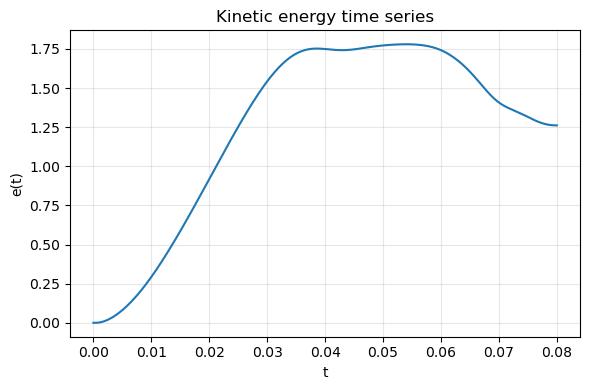

In [38]:
t_arr = np.arange(len(energy_hist)) * delta_t

plt.figure(figsize=(6,4))
plt.plot(t_arr, energy_hist, lw=1.5)
plt.xlabel("t")
plt.ylabel("e(t)")
plt.title("Kinetic energy time series")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / "Kinetic energy time series.png")
plt.show()

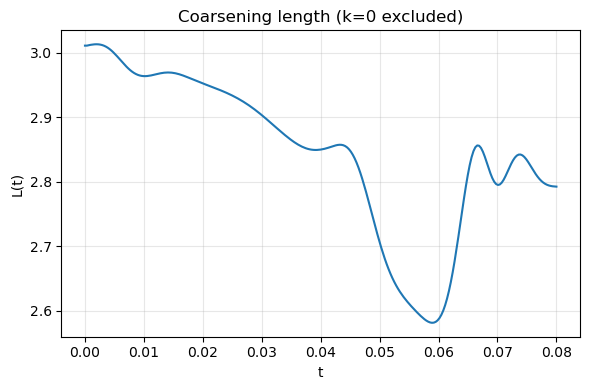

In [39]:
L_arr = np.array(L_hist)

plt.figure(figsize=(6,4))
plt.plot(t_arr, L_arr, lw=1.5)
plt.xlabel("t")
plt.ylabel("L(t)")
plt.title("Coarsening length (k=0 excluded)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / "Coarsening length (k=0 excluded).png")
plt.show()

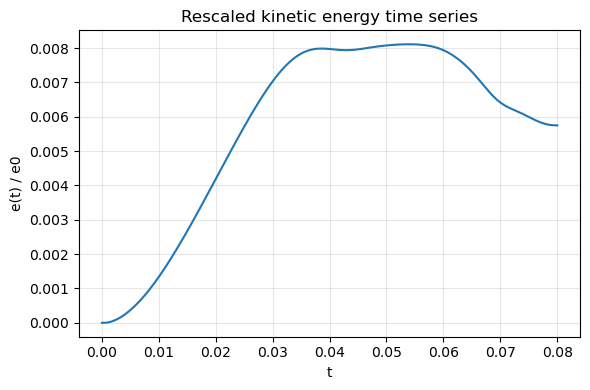

In [40]:
# Validation 04 - Regime classification and refinement

U = f_0 / (nu * k_f**2)
e0 = U**2

energy_hist = np.array(energy_hist)
energy_hist_scaled = energy_hist / e0
t_arr = np.arange(len(energy_hist_scaled)) * delta_t

plt.figure(figsize=(6,4))
plt.plot(t_arr, energy_hist_scaled, lw=1.5)
plt.xlabel("t")
plt.ylabel("e(t) / e0")
plt.title("Rescaled kinetic energy time series")
plt.grid(True, alpha=0.3)
plt.savefig(plots_dir / "Rescaled kinetic energy time series.png")
plt.tight_layout()
plt.show()

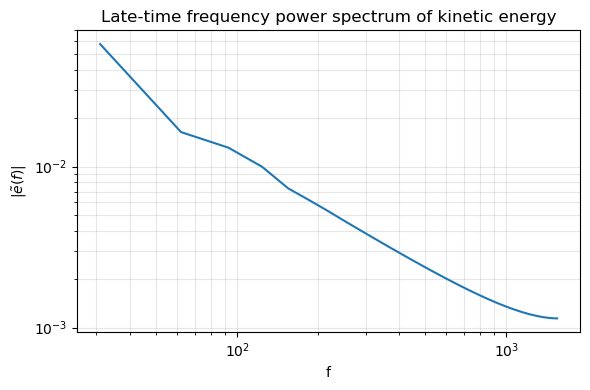

In [41]:
# A - Frequency spectrum of e(t)

e_arr = np.array(energy_hist_scaled)

# remove transient
start_frac = 0.6
i0 = int(start_frac * len(e_arr))

e_late = e_arr[i0:] - np.mean(e_arr[i0:])
e_fft = np.fft.rfft(e_late)
freqs = np.fft.rfftfreq(len(e_late), d=delta_t)

power_amp = np.abs(e_fft)     # closer to RP2 notation |\tilde e(f)|

plt.figure(figsize=(6,4))
plt.loglog(freqs[1:], power_amp[1:], lw=1.5)
plt.xlabel("f")
plt.ylabel(r"$|\tilde e(f)|$")
plt.title("Late-time frequency power spectrum of kinetic energy")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

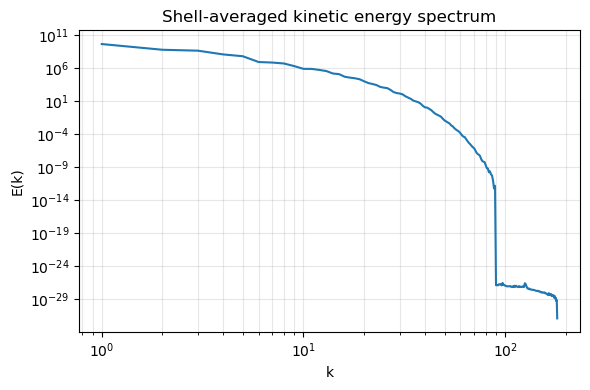

In [42]:
# B. Shell-averaged kinetic energy spectrum

def shell_average_energy(u_x_hat, u_y_hat, K2):
    k_mag = np.sqrt(K2)
    k_max = int(np.floor(np.max(k_mag)))
    E = np.zeros(k_max + 1)

    energy_density = 0.5 * (np.abs(u_x_hat)**2 + np.abs(u_y_hat)**2)

    for k in range(k_max + 1):
        mask = (k_mag >= k) & (k_mag < k + 1)
        if np.any(mask):
            E[k] = np.sum(energy_density[mask])

    return E

omega_hat_final = np.fft.fft2(omega_history[-1])
psi_hat = np.zeros_like(omega_hat_final, dtype=complex)
mask = (K2 != 0)
psi_hat[mask] = omega_hat_final[mask] / K2[mask]

u_x_hat = 1j * Ky * psi_hat
u_y_hat = -1j * Kx * psi_hat

E_k = shell_average_energy(u_x_hat, u_y_hat, K2)
kvals = np.arange(len(E_k))

plt.figure(figsize=(6,4))
plt.loglog(kvals[1:], E_k[1:], lw=1.5)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title("Shell-averaged kinetic energy spectrum")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [43]:
# # B. Grid/timestep refinement

# run256 = {
#     "phi_history": phi_history_256,
#     "omega_history": omega_history_256,
#     "energy_hist": energy_hist_256,
#     "L_hist": L_hist_256,
#     "delta_t": delta_t_256
# }

# run512 = {
#     "phi_history": phi_history_512,
#     "omega_history": omega_history_512,
#     "energy_hist": energy_hist_512,
#     "L_hist": L_hist_512,
#     "delta_t": delta_t_512
# }

# fig, axes = plt.subplots(2, 2, figsize=(10,8))

# im0 = axes[0,0].imshow(run256["phi_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='viridis')
# axes[0,0].set_title("phi final (256)")
# plt.colorbar(im0, ax=axes[0,0])

# im1 = axes[0,1].imshow(run512["phi_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='viridis')
# axes[0,1].set_title("phi final (512)")
# plt.colorbar(im1, ax=axes[0,1])

# im2 = axes[1,0].imshow(run256["omega_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='RdBu_r')
# axes[1,0].set_title("omega final (256)")
# plt.colorbar(im2, ax=axes[1,0])

# im3 = axes[1,1].imshow(run512["omega_history"][-1], origin='lower', extent=[0,L_x,0,L_y], cmap='RdBu_r')
# axes[1,1].set_title("omega final (512)")
# plt.colorbar(im3, ax=axes[1,1])

# plt.tight_layout()
# plt.show()

# t256 = np.arange(len(run256["energy_hist"])) * run256["delta_t"]
# t512 = np.arange(len(run512["energy_hist"])) * run512["delta_t"]

# fig, axes = plt.subplots(1, 2, figsize=(10,4))

# axes[0].plot(t256, run256["energy_hist"], label="256")
# axes[0].plot(t512, run512["energy_hist"], label="512")
# axes[0].set_xlabel("t")
# axes[0].set_ylabel("e(t)")
# axes[0].set_title("Kinetic energy")
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(t256, run256["L_hist"], label="256")
# axes[1].plot(t512, run512["L_hist"], label="512")
# axes[1].set_xlabel("t")
# axes[1].set_ylabel("L(t)")
# axes[1].set_title("Coarsening length")
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# def power_spectrum_from_energy(energy_hist, delta_t, start_frac=0.5):
#     e = np.array(energy_hist)
#     i0 = int(start_frac * len(e))
#     e = e[i0:] - np.mean(e[i0:])
#     e_fft = np.fft.rfft(e)
#     freqs = np.fft.rfftfreq(len(e), d=delta_t)
#     power = np.abs(e_fft)**2
#     return freqs, power

# f256, p256 = power_spectrum_from_energy(run256["energy_hist"], run256["delta_t"])
# f512, p512 = power_spectrum_from_energy(run512["energy_hist"], run512["delta_t"])

# plt.figure(figsize=(6,4))
# plt.loglog(f256[1:], p256[1:], label="256")
# plt.loglog(f512[1:], p512[1:], label="512")
# plt.xlabel("f")
# plt.ylabel(r"$|\tilde e(f)|^2$")
# plt.title("Late-time energy spectra")
# plt.legend()
# plt.grid(True, alpha=0.3, which='both')
# plt.tight_layout()
# plt.show()

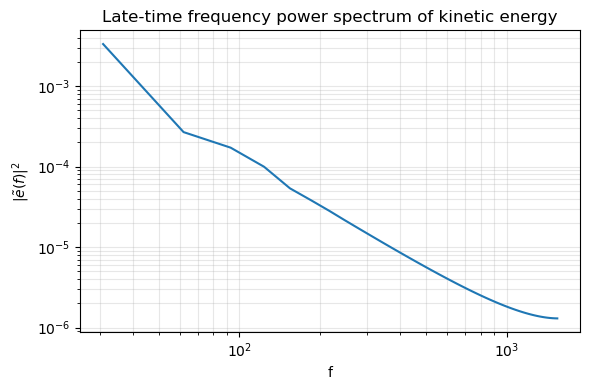

In [44]:
e_late = e_arr[i0:] - np.mean(e_arr[i0:])

e_fft = np.fft.rfft(e_late)
freqs = np.fft.rfftfreq(len(e_late), d=delta_t)
power = np.abs(e_fft)**2

plt.figure(figsize=(6,4))
plt.loglog(freqs[1:], power[1:], lw=1.5)
plt.xlabel("f")
plt.ylabel(r"$|\tilde e(f)|^2$")
plt.title("Late-time frequency power spectrum of kinetic energy")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

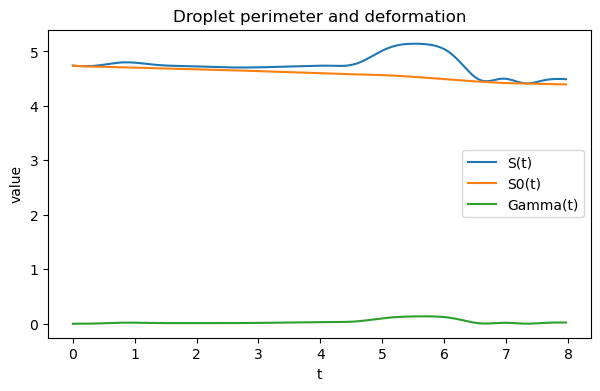

In [45]:
# Perimeter, reference perimeter, deformation

plt.figure(figsize=(7, 4))
plt.plot(track["time"], track["perimeter"], label="S(t)")
plt.plot(track["time"], track["S0"], label="S0(t)")
plt.plot(track["time"], track["gamma"], label="Gamma(t)")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.title("Droplet perimeter and deformation")
plt.savefig(plots_dir / "Droplet perimeter and deformation.png")
plt.show()

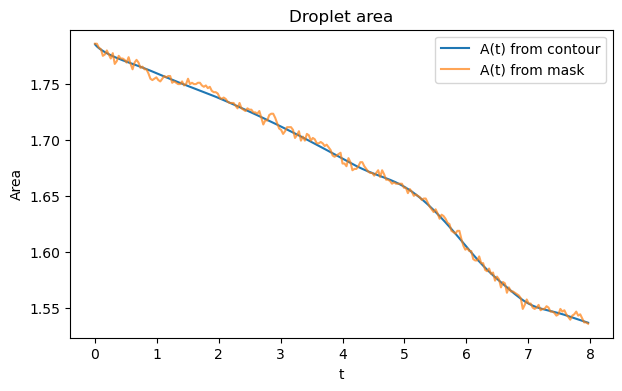

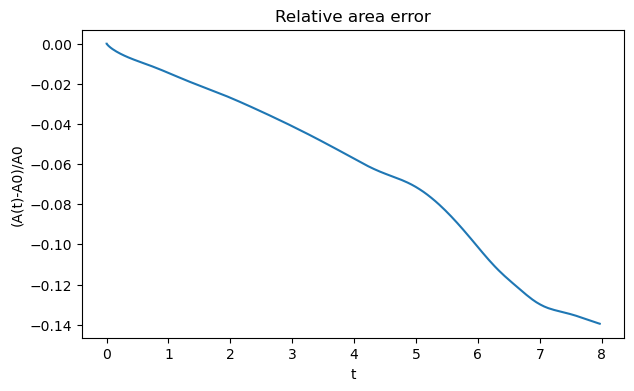

In [46]:
# Area conservation

plt.figure(figsize=(7, 4))
plt.plot(track["time"], track["area"], label="A(t) from contour")
plt.plot(track["time"], track["area_mask"], label="A(t) from mask", alpha=0.7)
plt.xlabel("t")
plt.ylabel("Area")
plt.legend()
plt.title("Droplet area")
plt.savefig(plots_dir / "Droplet area.png")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(track["time"], track["area_rel_error"])
plt.xlabel("t")
plt.ylabel("(A(t)-A0)/A0")
plt.title("Relative area error")
plt.savefig(plots_dir / "Relative area error.png")
plt.show()


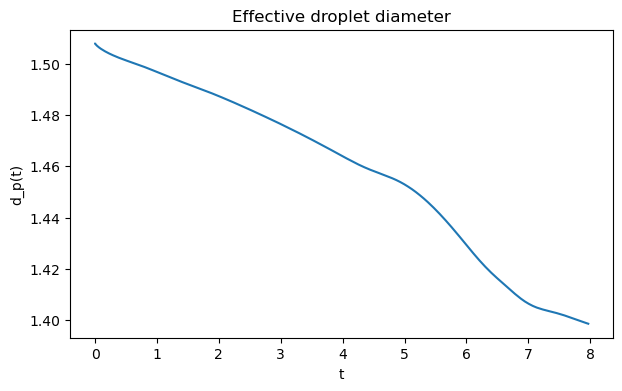

In [47]:
# Effective droplet diameter

plt.figure(figsize=(7, 4))
plt.plot(track["time"], track["diameter"])
plt.xlabel("t")
plt.ylabel("d_p(t)")
plt.title("Effective droplet diameter")
plt.savefig(plots_dir / "Effective droplet diameter.png")
plt.show()

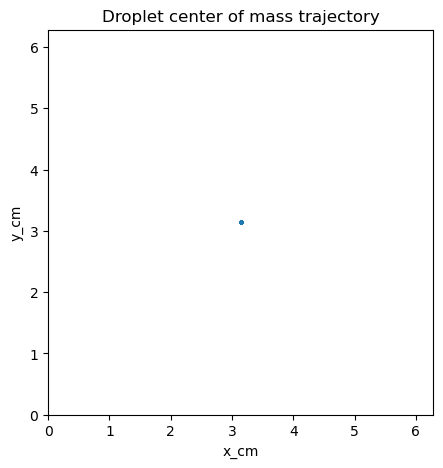

In [48]:
# Center of mass trajectory

plt.figure(figsize=(5, 5))
plt.plot(track["x_cm"], track["y_cm"], "-o", markersize=2)
plt.xlabel("x_cm")
plt.ylabel("y_cm")
plt.title("Droplet center of mass trajectory")
plt.xlim(0, L_x)
plt.ylim(0, L_y)
plt.gca().set_aspect("equal")
plt.savefig(plots_dir / "Droplet center of mass trajectory.png")
plt.show()

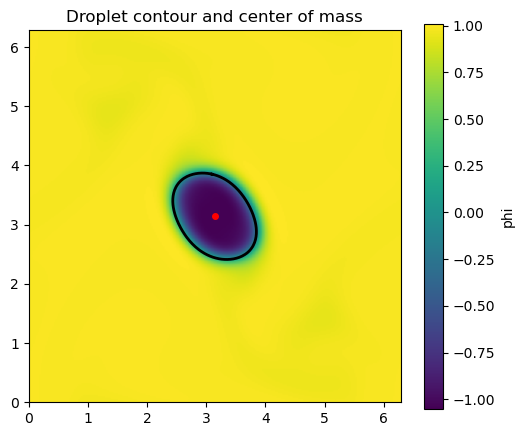

In [49]:
def plot_phi_with_contour(phi_xy, dx, dy, Lx, Ly):
    geom = droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0)
    plt.figure(figsize=(6, 5))
    plt.imshow(
        phi_xy,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        aspect="equal"
    )
    if geom is not None:
        plt.plot(geom["contour_x"], geom["contour_y"], "k-", linewidth=2)
        plt.plot(geom["x_cm"], geom["y_cm"], "ro", markersize=4)
    plt.colorbar(label="phi")
    plt.title("Droplet contour and center of mass")
    plt.show()

plot_phi_with_contour(phi_xy_final, del_x, del_y, L_x, L_y)